<a href="https://colab.research.google.com/github/J-Aamir/FineTuned-Finance-Models-Evaluation-using-Judge/blob/main/Mistral_Nemo_12b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# NOTEBOOK 3: Mistral-Nemo-12B — Curriculum Learning + DPO
# Financial QA | finance-alpaca dataset
# Features:
#   ✅ OOM-safe for Colab T4 (16GB)
#   ✅ Checkpoints every 300 steps (resume if disconnected)
#   ✅ Training graphs + visualizations at end
#   ✅ Combined graph slot ready for all 3 models
#   ✅ Deploy to HuggingFace Hub (J-Aamir)
# ============================================================

# ── CELL 1: Check GPU & RAM ───────────────────────────────────
import subprocess
gpu  = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(gpu.stdout)

# Also check RAM
ram = subprocess.run(['free', '-h'], capture_output=True, text=True)
print(ram.stdout)

# ── CELL 2: Install ───────────────────────────────────────────
# Uninstall everything first to avoid version conflicts
import subprocess
subprocess.run(['pip', 'uninstall', 'unsloth', 'unsloth_zoo', '-y'])

# Install pinned stable versions that are guaranteed compatible
get_ipython().system('pip install -q unsloth==2026.4.8')
get_ipython().system('pip install -q unsloth_zoo==2026.4.8')
get_ipython().system('pip install -q --no-deps trl peft accelerate bitsandbytes')
get_ipython().system('pip install -q datasets transformers huggingface_hub')
get_ipython().system('pip install -q matplotlib seaborn')

print("✅ Done — now go to Runtime → Restart session, then run from Cell 3")

# ── CELL 3: Mount Drive & set paths ──────────────────────────
from google.colab import drive
drive.mount('/content/drive')
import os, json, torch, gc
import numpy as np

BASE_DIR  = "/content/drive/MyDrive/assignment3/mistral_nemo_financial"
CKPT_SFT  = f"{BASE_DIR}/checkpoints_sft"
CKPT_DPO  = f"{BASE_DIR}/checkpoints_dpo"
GRAPHS_DIR = f"{BASE_DIR}/graphs"

for d in [BASE_DIR, CKPT_SFT, CKPT_DPO, GRAPHS_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Drive mounted")
print(f"   Base dir    : {BASE_DIR}")
print(f"   SFT ckpts   : {CKPT_SFT}")
print(f"   DPO ckpts   : {CKPT_DPO}")
print(f"   Graphs      : {GRAPHS_DIR}")

# ── CELL 4: Load Mistral-Nemo-12B (4-bit NF4) ────────────────
# Mistral-Nemo = 12B params
# 4-bit NF4 → ~6GB weights + ~4GB overhead = ~10GB total
# T4 has 16GB → ~6GB headroom for training ✅

from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = 512   # Conservative for 12B on T4 — prevents OOM
LOAD_IN_4BIT   = True

print("Loading Mistral-Nemo-12B in 4-bit NF4...")
print("Expected VRAM after load: ~10GB / 16GB")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/Mistral-Nemo-Instruct-2407-bnb-4bit",
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = LOAD_IN_4BIT,
)

print(f"✅ Mistral-Nemo-12B loaded")
print(f"   VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB / 16 GB")
print(f"   VRAM free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.2f} GB")

# ── CELL 5: Attach LoRA adapters ─────────────────────────────
model = FastLanguageModel.get_peft_model(
    model,
    r              = 8,     # Reduced from 16 → saves VRAM for 12B model
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha     = 16,    # Keep alpha = 2x rank
    lora_dropout   = 0.05,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",   # critical for 12B on T4
    random_state   = 42,
)
print("✅ LoRA adapters attached (r=8 for 12B memory safety)")
model.print_trainable_parameters()

# ── CELL 6: Load & engineer finance-alpaca dataset ───────────
from datasets import load_dataset, Dataset, concatenate_datasets

raw = load_dataset("gbharti/finance-alpaca", split="train")
print(f"Raw samples: {len(raw)}")

SYSTEM_PROMPT = (
    "You are an expert financial analyst and assistant. "
    "Provide accurate, well-structured, and insightful answers "
    "to financial questions."
)

# Mistral-Nemo uses [INST] format
def format_nemo(inst, inp, out):
    context  = inp.strip() if inp and inp.strip() else ""
    user_msg = f"{inst}\n\nContext: {context}" if context else inst
    return (
        f"<s>[INST] {SYSTEM_PROMPT}\n\n{user_msg} [/INST] "
        f"{out}</s>"
    )

def format_dataset(examples):
    texts = [
        format_nemo(i, inp, o)
        for i, inp, o in zip(
            examples["instruction"],
            examples["input"],
            examples["output"]
        )
    ]
    return {
        "text"       : texts,
        "instruction": examples["instruction"],
        "input"      : examples["input"],
        "output"     : examples["output"],
    }

dataset = raw.map(format_dataset, batched=True)

# Filter: 80–500 tokens (tighter than other models due to 12B memory)
def filter_fn(example):
    n = len(tokenizer(example["text"])["input_ids"])
    return 80 < n < 500

dataset = dataset.filter(filter_fn)
print(f"After filtering: {len(dataset)} samples")

# ── CELL 7: CURRICULUM LEARNING — Sort easy → hard ───────────
print("\n📚 Applying Curriculum Learning...")

def get_answer_length(example):
    return {"answer_len": len(tokenizer(example["output"])["input_ids"])}

dataset = dataset.map(get_answer_length)
dataset = dataset.sort("answer_len")   # easy first, hard last

n          = len(dataset)
easy_end   = n // 3
medium_end = 2 * n // 3

easy_data   = dataset.select(range(0, easy_end))
medium_data = dataset.select(range(easy_end, medium_end))
hard_data   = dataset.select(range(medium_end, n))

# Curriculum weighting: 40% easy → 35% medium → 25% hard
easy_sample   = easy_data.shuffle(42).select(range(min(2400, len(easy_data))))
medium_sample = medium_data.shuffle(42).select(range(min(2100, len(medium_data))))
hard_sample   = hard_data.shuffle(42).select(range(min(1500, len(hard_data))))

# DO NOT shuffle — order is the curriculum
curriculum_dataset = concatenate_datasets([easy_sample, medium_sample, hard_sample])

print(f"✅ Curriculum dataset: {len(curriculum_dataset)} total samples")
print(f"   Easy:   {len(easy_sample):,}  (short answers  — financial basics)")
print(f"   Medium: {len(medium_sample):,}  (medium answers — intermediate concepts)")
print(f"   Hard:   {len(hard_sample):,}  (long answers   — complex financial reasoning)")
print(f"   Training order: Easy → Medium → Hard (not shuffled)")

# ── CELL 8: Custom callback to log loss for graphs ───────────
from transformers import TrainerCallback

class LossLogger(TrainerCallback):
    """Logs training loss at every step for visualization later."""
    def __init__(self):
        self.sft_steps  = []
        self.sft_losses = []
        self.dpo_steps  = []
        self.dpo_losses = []
        self._stage     = "sft"

    def set_stage(self, stage):
        self._stage = stage   # "sft" or "dpo"

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            if self._stage == "sft":
                self.sft_steps.append(state.global_step)
                self.sft_losses.append(logs["loss"])
            else:
                self.dpo_steps.append(state.global_step)
                self.dpo_losses.append(logs["loss"])

loss_logger = LossLogger()
print("✅ Loss logger ready")

# ── CELL 9: STAGE 1 — Curriculum SFT ─────────────────────────
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

print("\n" + "="*60)
print("STAGE 1: Curriculum SFT Training — Mistral-Nemo-12B")
print("="*60)

# Resume from checkpoint if exists
existing_sft = sorted(
    [d for d in os.listdir(CKPT_SFT) if d.startswith("checkpoint-")],
    key=lambda x: int(x.split("-")[1])
) if os.path.exists(CKPT_SFT) else []

resume_sft = os.path.join(CKPT_SFT, existing_sft[-1]) if existing_sft else None
print(f"{'🔄 Resuming from: ' + existing_sft[-1] if resume_sft else '🚀 Starting from scratch'}")

loss_logger.set_stage("sft")

sft_trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = curriculum_dataset,
    dataset_text_field = "text",
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 2,
    packing            = False,
    callbacks          = [loss_logger],
    args = TrainingArguments(
        # OOM-safe batch settings for 12B
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8,   # effective batch = 8
        max_grad_norm               = 0.3,

        num_train_epochs  = 2,
        warmup_steps      = 100,
        learning_rate     = 2e-4,

        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),

        optim             = "adamw_8bit",
        weight_decay      = 0.01,
        lr_scheduler_type = "cosine",

        logging_steps    = 25,

        # Checkpoint every 300 steps → survives disconnection
        save_strategy    = "steps",
        save_steps       = 300,
        save_total_limit = 3,
        output_dir       = CKPT_SFT,

        seed      = 42,
        report_to = "none",
    ),
)

sft_stats = sft_trainer.train(resume_from_checkpoint=resume_sft)
print(f"\n✅ Stage 1 complete! SFT loss: {sft_stats.training_loss:.4f}")

# Save SFT-only model (before DPO modifies it)
SFT_MODEL_DIR = f"{BASE_DIR}/sft_model"
os.makedirs(SFT_MODEL_DIR, exist_ok=True)
model.save_pretrained(SFT_MODEL_DIR)
tokenizer.save_pretrained(SFT_MODEL_DIR)
print(f"✅ SFT model saved to Drive")






Sun May  3 13:21:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

ValueError: mount failed

In [ ]:
# ── CELL 10: Build DPO preference dataset ────────────────────
# Fresh data SFT never saw — different seed, different slice
from datasets import load_dataset as _load
_fresh     = _load("gbharti/finance-alpaca", split="train")
_fresh     = _fresh.shuffle(seed=99)
_fresh     = _fresh.filter(lambda x: len(x["output"].split()) > 20)
dpo_source = _fresh.select(range(10000, 12000))   # 2000 fresh samples ✅

print("\n" + "="*60)
print("Building DPO Preference Dataset")
print("="*60)

FINANCIAL_REPLACEMENTS = {
    "interest rate"  : "the percentage charged",
    "dividend"       : "payment to shareholders",
    "equity"         : "ownership stake",
    "portfolio"      : "collection of investments",
    "inflation"      : "general price increase",
    "liquidity"      : "how easily assets convert to cash",
    "volatility"     : "price fluctuation",
    "asset"          : "valuable item",
    "liability"      : "financial obligation",
    "revenue"        : "total income",
    "yield"          : "return percentage",
    "leverage"       : "use of borrowed money",
    "hedge"          : "risk reduction strategy",
    "derivative"     : "financial contract",
    "amortization"   : "gradual debt repayment",
    "arbitrage"      : "price difference exploitation",
    "fiscal policy"  : "government spending decisions",
    "monetary policy": "central bank decisions",
}

HEDGE_PREFIXES = [
    "It's quite complicated, but essentially ",
    "This is difficult to explain simply, however ",
    "Without getting too technical, ",
    "In very basic terms, ",
    "To put it simply (though it's more complex), ",
]

def make_rejected(correct_answer):
    words     = correct_answer.split()
    cutoff    = max(12, int(len(words) * 0.4))
    truncated = " ".join(words[:cutoff])
    for term, vague in FINANCIAL_REPLACEMENTS.items():
        truncated = truncated.lower().replace(term, vague)
    return random.choice(HEDGE_PREFIXES) + truncated + "..."

def build_prompt(inst, inp):
    context  = inp.strip() if inp and inp.strip() else ""
    user_msg = f"{inst}\n\nContext: {context}" if context else inst
    return f"<s>[INST] {SYSTEM_PROMPT}\n\n{user_msg} [/INST] "

# ← OLD LINE DELETED — dpo_source already set at top ✅

dpo_records = []
for ex in dpo_source:
    if len(ex["output"].split()) < 20:
        continue
    dpo_records.append({
        "prompt"  : build_prompt(ex["instruction"], ex["input"]),
        "chosen"  : ex["output"],
        "rejected": make_rejected(ex["output"]),
    })

dpo_dataset = Dataset.from_list(dpo_records)
print(f"✅ DPO dataset: {len(dpo_dataset)} preference pairs")
print(f"\nSample:")
print(f"  Chosen   (first 100 chars): {dpo_dataset[0]['chosen'][:100]}...")
print(f"  Rejected (first 100 chars): {dpo_dataset[0]['rejected'][:100]}...")

# ── CELL 11: STAGE 2 — DPO Training ──────────────────────────
from trl import DPOTrainer, DPOConfig

print("\n" + "="*60)
print("STAGE 2: DPO Alignment — Mistral-Nemo-12B")
print("="*60)

# Free memory before DPO
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM before DPO: {torch.cuda.memory_allocated()/1e9:.2f} GB")

FastLanguageModel.for_training(model)
loss_logger.set_stage("dpo")

existing_dpo = sorted(
    [d for d in os.listdir(CKPT_DPO) if d.startswith("checkpoint-")],
    key=lambda x: int(x.split("-")[1])
) if os.path.exists(CKPT_DPO) else []

resume_dpo = os.path.join(CKPT_DPO, existing_dpo[-1]) if existing_dpo else None
print(f"{'🔄 Resuming DPO from: ' + existing_dpo[-1] if resume_dpo else '🚀 Starting DPO from scratch'}")

dpo_config = DPOConfig(
    beta              = 0.1,       # KL penalty — standard value
    loss_type         = "sigmoid",

    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 4,   # smaller — DPO pairs use 2x memory
    max_grad_norm               = 0.3,

    num_train_epochs  = 1,
    warmup_steps      = 50,
    learning_rate     = 5e-5,   # lower LR — fine-tuning alignment only
    fp16 = not is_bfloat16_supported(),
    bf16 = is_bfloat16_supported(),
    optim             = "adamw_8bit",
    lr_scheduler_type = "cosine",

    max_length        = 512,
    max_prompt_length = 256,

    logging_steps    = 25,
    save_strategy    = "steps",
    save_steps       = 300,
    save_total_limit = 3,
    output_dir       = CKPT_DPO,

    seed      = 42,
    report_to = "none",
)

dpo_trainer = DPOTrainer(
    model         = model,
    args          = dpo_config,
    train_dataset = dpo_dataset,
    tokenizer     = tokenizer,
    callbacks     = [loss_logger],
)

dpo_stats = dpo_trainer.train(resume_from_checkpoint=resume_dpo)
print(f"\n✅ Stage 2 complete! DPO loss: {dpo_stats.training_loss:.4f}")

# ── CELL 12: Save final model to Drive ───────────────────────
print("\n💾 Saving final model to Drive...")
model.save_pretrained(BASE_DIR)
tokenizer.save_pretrained(BASE_DIR)

training_stats = {
    "model"  : "Mistral-Nemo-12B-Instruct",
    "method" : "Curriculum SFT + DPO",
    "dataset": "finance-alpaca",
    "curriculum": {
        "easy_samples"  : len(easy_sample),
        "medium_samples": len(medium_sample),
        "hard_samples"  : len(hard_sample),
        "total"         : len(curriculum_dataset),
        "sft_final_loss": sft_stats.training_loss,
        "sft_steps"     : loss_logger.sft_steps,
        "sft_losses"    : loss_logger.sft_losses,
    },
    "dpo": {
        "pairs"         : len(dpo_dataset),
        "beta"          : 0.1,
        "dpo_final_loss": dpo_stats.training_loss,
        "dpo_steps"     : loss_logger.dpo_steps,
        "dpo_losses"    : loss_logger.dpo_losses,
    },
}

with open(f"{BASE_DIR}/training_stats.json", "w") as f:
    json.dump(training_stats, f, indent=2)

print(f"✅ Model + stats saved to {BASE_DIR}")


Mounted at /content/drive
EXTRACTING SFT LOSS FROM CHECKPOINTS

📂 SFT checkpoints found: ['checkpoint-900', 'checkpoint-1200', 'checkpoint-1500']
   ✅ checkpoint-900: 36 log entries read
   ✅ checkpoint-1200: 48 log entries read
   ✅ checkpoint-1500: 60 log entries read

   📊 SFT Summary:
      Total steps logged : 60
      First step         : 25
      Last step          : 1500
      Starting loss      : 2.607855
      Final loss         : 1.293230
      Best loss          : 1.278238 (step 1125)
      Total improvement  : 1.314625

EXTRACTING DPO LOSS FROM CHECKPOINTS

📂 DPO checkpoints found: ['checkpoint-300', 'checkpoint-500']
   ✅ checkpoint-300: 12 log entries read
   ✅ checkpoint-500: 20 log entries read

   📊 DPO Summary:
      Total steps logged : 20
      First step         : 25
      Last step          : 500
      Starting loss      : 0.186918
      Final loss         : 0.000043
      Best loss          : 0.000014 (step 275)
      Total improvement  : 0.186875

FULL LOSS TAB

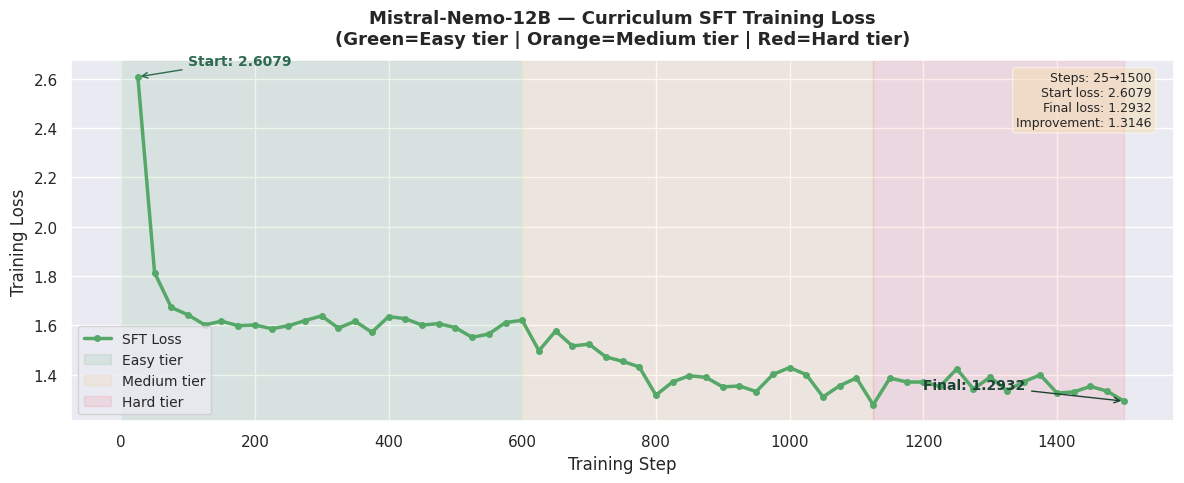

✅ SFT graph saved: /content/drive/MyDrive/assignment3/mistral_nemo_financial/graphs/nemo_sft_loss.png


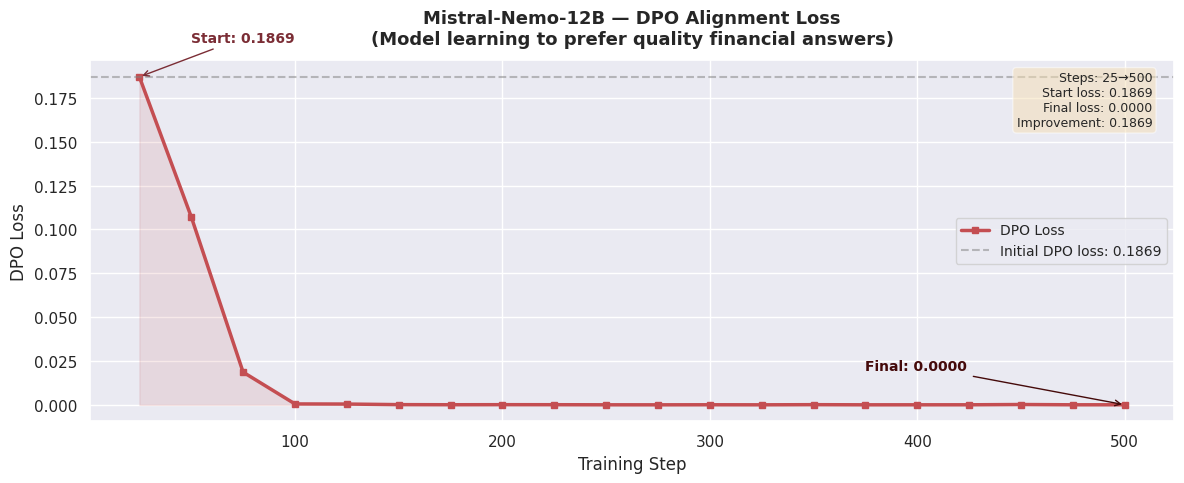

✅ DPO graph saved: /content/drive/MyDrive/assignment3/mistral_nemo_financial/graphs/nemo_dpo_loss.png


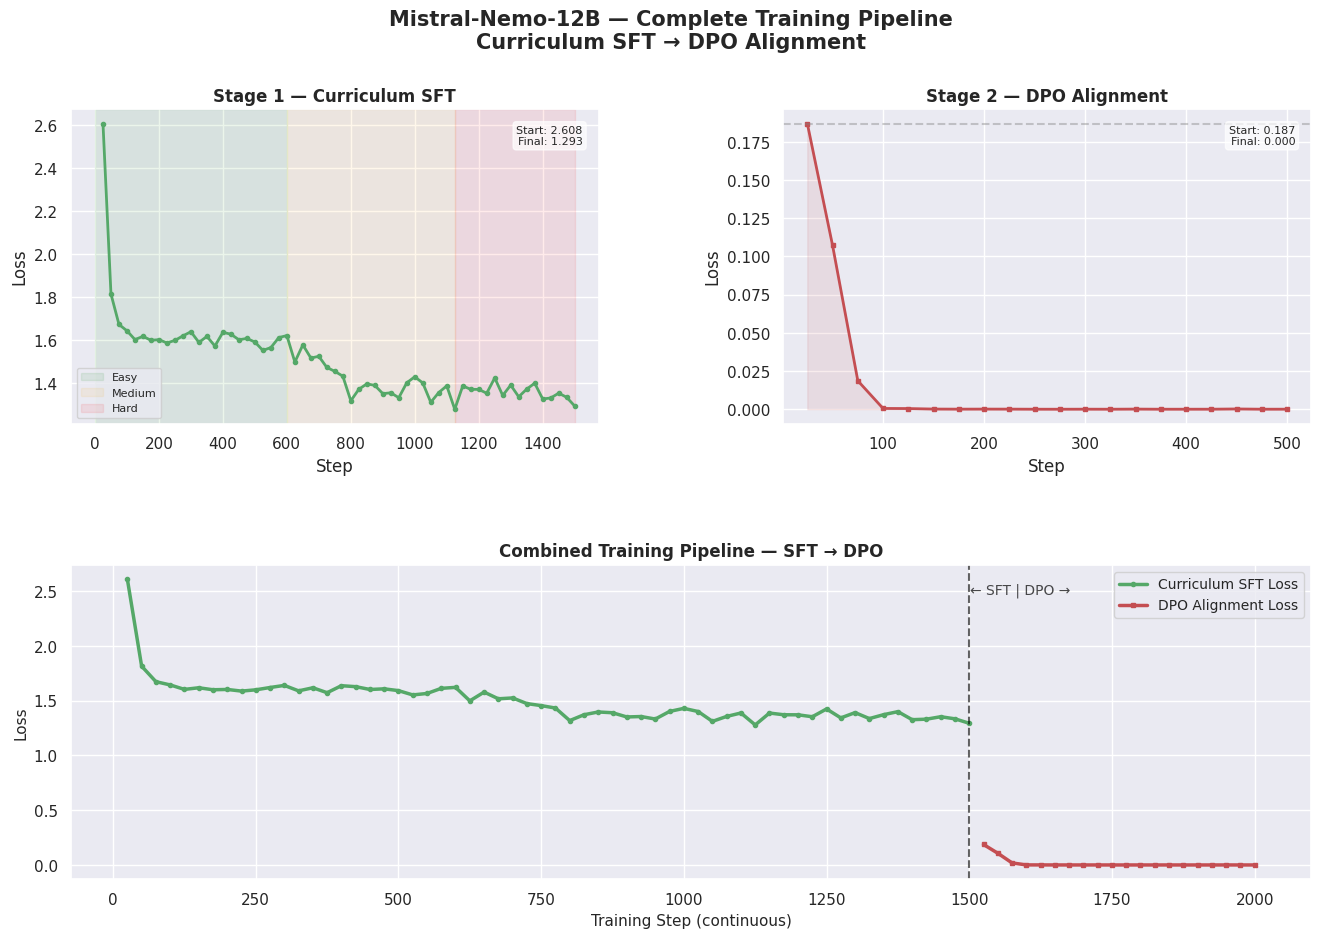

✅ Combined graph saved: /content/drive/MyDrive/assignment3/mistral_nemo_financial/graphs/nemo_combined_sft_dpo.png

✅ Loss data saved to training_stats.json

COMPLETE TRAINING SUMMARY — MISTRAL-NEMO-12B

Stage 1 — Curriculum SFT:
  Steps logged  : 60
  Step range    : 25 → 1500
  Starting loss : 2.607855
  Final loss    : 1.293230
  Best loss     : 1.278238
  Total drop    : 1.314625

Stage 2 — DPO Alignment:
  Steps logged  : 20
  Step range    : 25 → 500
  Starting loss : 0.186918
  Final loss    : 0.000043
  Best loss     : 0.000014
  Total drop    : 0.186875

📊 Graphs saved to: /content/drive/MyDrive/assignment3/mistral_nemo_financial/graphs
   nemo_sft_loss.png          ← SFT curve with tier shading
   nemo_dpo_loss.png          ← DPO alignment curve
   nemo_combined_sft_dpo.png  ← USE THIS IN REPORT ⭐


In [ ]:
# ============================================================
# GRAPH RECOVERY: Mistral-Nemo-12B
# Extract real loss from checkpoints → SFT graph → DPO graph
# → Combined graph
# Run as a single cell or separate cells in Colab
# ============================================================

import json, os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

from google.colab import drive
drive.mount('/content/drive')


sns.set_theme(style="darkgrid")

# ── Paths ─────────────────────────────────────────────────────
BASE_DIR  = "/content/drive/MyDrive/assignment3/mistral_nemo_financial"
CKPT_SFT  = f"{BASE_DIR}/checkpoints_sft"
CKPT_DPO  = f"{BASE_DIR}/checkpoints_dpo"
GRAPHS_DIR = f"{BASE_DIR}/graphs"
os.makedirs(GRAPHS_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════
# STEP 1: EXTRACT LOSS FROM ALL CHECKPOINTS
# ══════════════════════════════════════════════════════════════

def extract_loss_from_checkpoints(ckpt_dir, stage_name):
    """
    Reads trainer_state.json from every checkpoint folder.
    Merges all loss entries and deduplicates by step.
    Returns sorted (steps, losses) lists.
    """
    if not os.path.exists(ckpt_dir):
        print(f"❌ {stage_name} checkpoint dir not found: {ckpt_dir}")
        return [], []

    ckpts = sorted(
        [d for d in os.listdir(ckpt_dir) if d.startswith("checkpoint-")],
        key=lambda x: int(x.split("-")[1])
    )

    if not ckpts:
        print(f"❌ No checkpoints found in {ckpt_dir}")
        return [], []

    print(f"\n📂 {stage_name} checkpoints found: {ckpts}")

    # Merge loss history from ALL checkpoints
    # Later checkpoints contain history of earlier ones too,
    # but we read all to be safe and deduplicate
    all_entries = {}   # step → loss (dict deduplicates)

    for ckpt in ckpts:
        state_path = os.path.join(ckpt_dir, ckpt, "trainer_state.json")
        if not os.path.exists(state_path):
            print(f"   ⚠️  No trainer_state.json in {ckpt}")
            continue

        with open(state_path) as f:
            state = json.load(f)

        log_history = state.get("log_history", [])
        for entry in log_history:
            if "loss" in entry and "step" in entry:
                all_entries[entry["step"]] = entry["loss"]

        print(f"   ✅ {ckpt}: {len(log_history)} log entries read")

    if not all_entries:
        print(f"   ❌ No loss entries found in any {stage_name} checkpoint")
        return [], []

    # Sort by step
    sorted_steps  = sorted(all_entries.keys())
    sorted_losses = [all_entries[s] for s in sorted_steps]

    print(f"\n   📊 {stage_name} Summary:")
    print(f"      Total steps logged : {len(sorted_steps)}")
    print(f"      First step         : {sorted_steps[0]}")
    print(f"      Last step          : {sorted_steps[-1]}")
    print(f"      Starting loss      : {sorted_losses[0]:.6f}")
    print(f"      Final loss         : {sorted_losses[-1]:.6f}")
    print(f"      Best loss          : {min(sorted_losses):.6f} (step {sorted_steps[sorted_losses.index(min(sorted_losses))]})")
    print(f"      Total improvement  : {sorted_losses[0] - sorted_losses[-1]:.6f}")

    return sorted_steps, sorted_losses

# Extract SFT loss
print("="*60)
print("EXTRACTING SFT LOSS FROM CHECKPOINTS")
print("="*60)
sft_steps, sft_losses = extract_loss_from_checkpoints(CKPT_SFT, "SFT")

# Extract DPO loss
print("\n" + "="*60)
print("EXTRACTING DPO LOSS FROM CHECKPOINTS")
print("="*60)
dpo_steps, dpo_losses = extract_loss_from_checkpoints(CKPT_DPO, "DPO")

# Print full loss table
print("\n" + "="*60)
print("FULL LOSS TABLE — SFT")
print("="*60)
print(f"{'Step':>8}  {'Loss':>12}")
print("-"*25)
for s, l in zip(sft_steps, sft_losses):
    print(f"{s:>8}  {l:>12.6f}")

print("\n" + "="*60)
print("FULL LOSS TABLE — DPO")
print("="*60)
print(f"{'Step':>8}  {'Loss':>12}")
print("-"*25)
for s, l in zip(dpo_steps, dpo_losses):
    print(f"{s:>8}  {l:>12.6f}")

# ══════════════════════════════════════════════════════════════
# STEP 2: GRAPH 1 — SFT Loss Curve
# ══════════════════════════════════════════════════════════════
if sft_steps:
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(sft_steps, sft_losses,
            color="#55A868", linewidth=2.5,
            marker='o', markersize=4, label="SFT Loss")

    # Shade curriculum tiers based on step range
    # Easy = first 40%, Medium = next 35%, Hard = last 25%
    max_step = sft_steps[-1]
    ax.axvspan(0,              max_step*0.40,
               alpha=0.08, color='green',  label='Easy tier')
    ax.axvspan(max_step*0.40,  max_step*0.75,
               alpha=0.08, color='orange', label='Medium tier')
    ax.axvspan(max_step*0.75,  max_step,
               alpha=0.08, color='red',    label='Hard tier')

    # Annotate start and end loss
    ax.annotate(f'Start: {sft_losses[0]:.4f}',
                xy=(sft_steps[0], sft_losses[0]),
                xytext=(sft_steps[0] + max_step*0.05, sft_losses[0] + 0.05),
                fontsize=10, color='#2d6a4f', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#2d6a4f'))

    ax.annotate(f'Final: {sft_losses[-1]:.4f}',
                xy=(sft_steps[-1], sft_losses[-1]),
                xytext=(sft_steps[-1] - max_step*0.2, sft_losses[-1] + 0.05),
                fontsize=10, color='#1b4332', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#1b4332'))

    ax.set_title("Mistral-Nemo-12B — Curriculum SFT Training Loss\n"
                 "(Green=Easy tier | Orange=Medium tier | Red=Hard tier)",
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("Training Step", fontsize=12)
    ax.set_ylabel("Training Loss",  fontsize=12)
    ax.legend(fontsize=10)

    # Add stats text box
    stats_text = (
        f"Steps: {sft_steps[0]}→{sft_steps[-1]}\n"
        f"Start loss: {sft_losses[0]:.4f}\n"
        f"Final loss: {sft_losses[-1]:.4f}\n"
        f"Improvement: {sft_losses[0]-sft_losses[-1]:.4f}"
    )
    ax.text(0.98, 0.97, stats_text,
            transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    sft_path = f"{GRAPHS_DIR}/nemo_sft_loss.png"
    plt.savefig(sft_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ SFT graph saved: {sft_path}")
else:
    print("⚠️  No SFT data — skipping SFT graph")

# ══════════════════════════════════════════════════════════════
# STEP 3: GRAPH 2 — DPO Loss Curve
# ══════════════════════════════════════════════════════════════
if dpo_steps:
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(dpo_steps, dpo_losses,
            color="#C44E52", linewidth=2.5,
            marker='s', markersize=4, label="DPO Loss")

    ax.fill_between(dpo_steps, dpo_losses,
                    alpha=0.12, color="#C44E52")

    # Reference line at start
    ax.axhline(y=dpo_losses[0], color='gray',
               linestyle='--', alpha=0.5,
               label=f'Initial DPO loss: {dpo_losses[0]:.4f}')

    # Annotate
    max_step_dpo = dpo_steps[-1]
    ax.annotate(f'Start: {dpo_losses[0]:.4f}',
                xy=(dpo_steps[0], dpo_losses[0]),
                xytext=(dpo_steps[0] + max_step_dpo*0.05,
                        dpo_losses[0] + 0.02),
                fontsize=10, color='#7b2d35', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#7b2d35'))

    ax.annotate(f'Final: {dpo_losses[-1]:.4f}',
                xy=(dpo_steps[-1], dpo_losses[-1]),
                xytext=(dpo_steps[-1] - max_step_dpo*0.25,
                        dpo_losses[-1] + 0.02),
                fontsize=10, color='#450a0a', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#450a0a'))

    ax.set_title("Mistral-Nemo-12B — DPO Alignment Loss\n"
                 "(Model learning to prefer quality financial answers)",
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("Training Step", fontsize=12)
    ax.set_ylabel("DPO Loss",      fontsize=12)
    ax.legend(fontsize=10)

    stats_text = (
        f"Steps: {dpo_steps[0]}→{dpo_steps[-1]}\n"
        f"Start loss: {dpo_losses[0]:.4f}\n"
        f"Final loss: {dpo_losses[-1]:.4f}\n"
        f"Improvement: {dpo_losses[0]-dpo_losses[-1]:.4f}"
    )
    ax.text(0.98, 0.97, stats_text,
            transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    dpo_path = f"{GRAPHS_DIR}/nemo_dpo_loss.png"
    plt.savefig(dpo_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ DPO graph saved: {dpo_path}")
else:
    print("⚠️  No DPO data — skipping DPO graph")

# ══════════════════════════════════════════════════════════════
# STEP 4: GRAPH 3 — Combined SFT + DPO (the main report graph)
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Mistral-Nemo-12B — Complete Training Pipeline\n"
             "Curriculum SFT → DPO Alignment",
             fontsize=15, fontweight='bold')

gs  = gridspec.GridSpec(2, 2, figure=fig,
                         hspace=0.45, wspace=0.35)

ax_sft      = fig.add_subplot(gs[0, 0])   # SFT alone
ax_dpo      = fig.add_subplot(gs[0, 1])   # DPO alone
ax_combined = fig.add_subplot(gs[1, :])   # full width combined

# ── Top left: SFT ────────────────────────────────────────────
if sft_steps:
    ax_sft.plot(sft_steps, sft_losses,
                color="#55A868", linewidth=2,
                marker='o', markersize=3)
    max_s = sft_steps[-1]
    ax_sft.axvspan(0,         max_s*0.40, alpha=0.08,
                   color='green',  label='Easy')
    ax_sft.axvspan(max_s*0.40, max_s*0.75, alpha=0.08,
                   color='orange', label='Medium')
    ax_sft.axvspan(max_s*0.75, max_s,      alpha=0.08,
                   color='red',    label='Hard')
    ax_sft.legend(fontsize=8)
    ax_sft.set_title("Stage 1 — Curriculum SFT", fontweight='bold')
    ax_sft.set_xlabel("Step"); ax_sft.set_ylabel("Loss")
    ax_sft.text(0.97, 0.95,
                f"Start: {sft_losses[0]:.3f}\nFinal: {sft_losses[-1]:.3f}",
                transform=ax_sft.transAxes, fontsize=8,
                ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
else:
    ax_sft.text(0.5, 0.5, "No SFT data", ha='center',
                transform=ax_sft.transAxes, fontsize=12, color='gray')
    ax_sft.set_title("Stage 1 — Curriculum SFT", fontweight='bold')

# ── Top right: DPO ───────────────────────────────────────────
if dpo_steps:
    ax_dpo.plot(dpo_steps, dpo_losses,
                color="#C44E52", linewidth=2,
                marker='s', markersize=3)
    ax_dpo.fill_between(dpo_steps, dpo_losses,
                        alpha=0.1, color="#C44E52")
    ax_dpo.axhline(y=dpo_losses[0], color='gray',
                   linestyle='--', alpha=0.4)
    ax_dpo.set_title("Stage 2 — DPO Alignment", fontweight='bold')
    ax_dpo.set_xlabel("Step"); ax_dpo.set_ylabel("Loss")
    ax_dpo.text(0.97, 0.95,
                f"Start: {dpo_losses[0]:.3f}\nFinal: {dpo_losses[-1]:.3f}",
                transform=ax_dpo.transAxes, fontsize=8,
                ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
else:
    ax_dpo.text(0.5, 0.5, "No DPO data", ha='center',
                transform=ax_dpo.transAxes, fontsize=12, color='gray')
    ax_dpo.set_title("Stage 2 — DPO Alignment", fontweight='bold')

# ── Bottom: Combined on one axis with stage divider ──────────
if sft_steps and dpo_steps:
    # Offset DPO steps to continue after SFT
    sft_end      = sft_steps[-1]
    dpo_offset   = [sft_end + s for s in dpo_steps]

    ax_combined.plot(sft_steps, sft_losses,
                     color="#55A868", linewidth=2.5,
                     marker='o', markersize=3,
                     label="Curriculum SFT Loss")
    ax_combined.plot(dpo_offset, dpo_losses,
                     color="#C44E52", linewidth=2.5,
                     marker='s', markersize=3,
                     label="DPO Alignment Loss")

    # Vertical line showing stage boundary
    ax_combined.axvline(x=sft_end, color='black',
                        linestyle='--', linewidth=1.5, alpha=0.6)
    ax_combined.text(sft_end + 2, max(sft_losses + dpo_losses)*0.95,
                     "← SFT | DPO →",
                     fontsize=10, color='black', alpha=0.7)

elif sft_steps:
    ax_combined.plot(sft_steps, sft_losses,
                     color="#55A868", linewidth=2.5,
                     label="Curriculum SFT Loss")
elif dpo_steps:
    ax_combined.plot(dpo_steps, dpo_losses,
                     color="#C44E52", linewidth=2.5,
                     label="DPO Alignment Loss")

ax_combined.set_title("Combined Training Pipeline — SFT → DPO",
                      fontweight='bold', fontsize=12)
ax_combined.set_xlabel("Training Step (continuous)", fontsize=11)
ax_combined.set_ylabel("Loss", fontsize=11)
ax_combined.legend(fontsize=10)

combined_path = f"{GRAPHS_DIR}/nemo_combined_sft_dpo.png"
plt.savefig(combined_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Combined graph saved: {combined_path}")

# ══════════════════════════════════════════════════════════════
# STEP 5: Save loss data to training_stats.json
# ══════════════════════════════════════════════════════════════
stats_path = f"{BASE_DIR}/training_stats.json"

# Load existing stats if present
if os.path.exists(stats_path):
    with open(stats_path) as f:
        existing_stats = json.load(f)
else:
    existing_stats = {}

# Update with real loss data
existing_stats.update({
    "model"  : "Mistral-Nemo-12B-Instruct",
    "method" : "Curriculum SFT + DPO",
    "curriculum": {
        **existing_stats.get("curriculum", {}),
        "sft_steps"      : sft_steps,
        "sft_losses"     : sft_losses,
        "sft_start_loss" : sft_losses[0]  if sft_losses else None,
        "sft_final_loss" : sft_losses[-1] if sft_losses else None,
        "sft_best_loss"  : min(sft_losses) if sft_losses else None,
    },
    "dpo": {
        **existing_stats.get("dpo", {}),
        "dpo_steps"      : dpo_steps,
        "dpo_losses"     : dpo_losses,
        "dpo_start_loss" : dpo_losses[0]  if dpo_losses else None,
        "dpo_final_loss" : dpo_losses[-1] if dpo_losses else None,
        "dpo_best_loss"  : min(dpo_losses) if dpo_losses else None,
    }
})

with open(stats_path, "w") as f:
    json.dump(existing_stats, f, indent=2)

print(f"\n✅ Loss data saved to training_stats.json")

# ══════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("COMPLETE TRAINING SUMMARY — MISTRAL-NEMO-12B")
print("="*60)

if sft_steps:
    print(f"\nStage 1 — Curriculum SFT:")
    print(f"  Steps logged  : {len(sft_steps)}")
    print(f"  Step range    : {sft_steps[0]} → {sft_steps[-1]}")
    print(f"  Starting loss : {sft_losses[0]:.6f}")
    print(f"  Final loss    : {sft_losses[-1]:.6f}")
    print(f"  Best loss     : {min(sft_losses):.6f}")
    print(f"  Total drop    : {sft_losses[0] - sft_losses[-1]:.6f}")

if dpo_steps:
    print(f"\nStage 2 — DPO Alignment:")
    print(f"  Steps logged  : {len(dpo_steps)}")
    print(f"  Step range    : {dpo_steps[0]} → {dpo_steps[-1]}")
    print(f"  Starting loss : {dpo_losses[0]:.6f}")
    print(f"  Final loss    : {dpo_losses[-1]:.6f}")
    print(f"  Best loss     : {min(dpo_losses):.6f}")
    print(f"  Total drop    : {dpo_losses[0] - dpo_losses[-1]:.6f}")

print(f"\n📊 Graphs saved to: {GRAPHS_DIR}")
print(f"   nemo_sft_loss.png          ← SFT curve with tier shading")
print(f"   nemo_dpo_loss.png          ← DPO alignment curve")
print(f"   nemo_combined_sft_dpo.png  ← USE THIS IN REPORT ⭐")
print("="*60)

In [ ]:
# ── CELL 13: VISUALIZATIONS ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="darkgrid")
COLORS = {
    "mistral_7b" : "#4C72B0",   # blue
    "qwen_25"    : "#DD8452",   # orange
    "nemo_12b"   : "#55A868",   # green
    "nemo_sft"   : "#55A868",
    "nemo_dpo"   : "#C44E52",   # red
}

# ── Graph 1: SFT Loss Curve (this model) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mistral-Nemo-12B: Training Loss Curves", fontsize=14, fontweight='bold')

# SFT loss
axes[0].plot(loss_logger.sft_steps, loss_logger.sft_losses,
             color=COLORS["nemo_sft"], linewidth=2, label="SFT Loss")
axes[0].set_title("Stage 1 — Curriculum SFT")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Loss")
axes[0].legend()

# DPO loss
axes[1].plot(loss_logger.dpo_steps, loss_logger.dpo_losses,
             color=COLORS["nemo_dpo"], linewidth=2, label="DPO Loss")
axes[1].set_title("Stage 2 — DPO Alignment")
axes[1].set_xlabel("Training Step")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{GRAPHS_DIR}/nemo_loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 1 saved: nemo_loss_curves.png")

# ── Graph 2: Curriculum distribution ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
tiers  = ['Easy\n(Short Answers)', 'Medium\n(Mid Answers)', 'Hard\n(Long Answers)']
counts = [len(easy_sample), len(medium_sample), len(hard_sample)]
bars   = ax.bar(tiers, counts,
                color=[COLORS["nemo_sft"], COLORS["mistral_7b"], COLORS["nemo_dpo"]],
                edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

ax.set_title("Curriculum Learning — Sample Distribution by Difficulty",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Number of Training Samples")
ax.set_xlabel("Difficulty Tier (Training Order: Left → Right)")
plt.tight_layout()
plt.savefig(f"{GRAPHS_DIR}/curriculum_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 2 saved: curriculum_distribution.png")

# ── Graph 3: COMBINED — All 3 models loss curves ─────────────
# Load loss data from Notebook 1 (Mistral-7B) and Notebook 2 (Qwen)
mistral_stats_path = "/content/drive/MyDrive/assignment3/mistral7b_financial/training_stats.json"
qwen_stats_path    = "/content/drive/MyDrive/assignment3/qwen25_7b_financial/training_stats.json"

fig = plt.figure(figsize=(16, 10))
fig.suptitle("All Models — Training Loss Comparison", fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])   # Mistral-7B
ax2 = fig.add_subplot(gs[0, 1])   # Qwen2.5-7B
ax3 = fig.add_subplot(gs[0, 2])   # Nemo SFT
ax4 = fig.add_subplot(gs[1, :])   # Combined overlay

# Mistral-7B loss
if os.path.exists(mistral_stats_path):
    with open(mistral_stats_path) as f:
        m_stats = json.load(f)
    m_steps  = m_stats.get("sft_steps",  [])
    m_losses = m_stats.get("sft_losses", [])
    if m_steps:
        ax1.plot(m_steps, m_losses, color=COLORS["mistral_7b"], linewidth=2)
        ax4.plot(m_steps, m_losses, color=COLORS["mistral_7b"],
                 linewidth=2, label="Mistral-7B (SFT)", alpha=0.85)
ax1.set_title("Mistral-7B — Standard SFT", fontweight='bold')
ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")

# Qwen2.5-7B loss
if os.path.exists(qwen_stats_path):
    with open(qwen_stats_path) as f:
        q_stats = json.load(f)
    q_steps  = q_stats.get("sft_steps",  [])
    q_losses = q_stats.get("sft_losses", [])
    if q_steps:
        ax2.plot(q_steps, q_losses, color=COLORS["qwen_25"], linewidth=2)
        ax4.plot(q_steps, q_losses, color=COLORS["qwen_25"],
                 linewidth=2, label="Qwen2.5-7B (SFT)", alpha=0.85)
ax2.set_title("Qwen2.5-7B — Improved SFT", fontweight='bold')
ax2.set_xlabel("Step"); ax2.set_ylabel("Loss")

# Nemo SFT loss
if loss_logger.sft_steps:
    ax3.plot(loss_logger.sft_steps, loss_logger.sft_losses,
             color=COLORS["nemo_sft"], linewidth=2)
    ax4.plot(loss_logger.sft_steps, loss_logger.sft_losses,
             color=COLORS["nemo_sft"], linewidth=2,
             label="Mistral-Nemo-12B (Curriculum SFT)", alpha=0.85)

    # Shade curriculum tiers on Nemo's individual plot
    total_steps = loss_logger.sft_steps[-1] if loss_logger.sft_steps else 1
    ax3.axvspan(0, total_steps*0.4, alpha=0.08,
                color='green', label='Easy tier')
    ax3.axvspan(total_steps*0.4, total_steps*0.75, alpha=0.08,
                color='orange', label='Medium tier')
    ax3.axvspan(total_steps*0.75, total_steps, alpha=0.08,
                color='red', label='Hard tier')
    ax3.legend(fontsize=7)

ax3.set_title("Mistral-Nemo-12B — Curriculum SFT", fontweight='bold')
ax3.set_xlabel("Step"); ax3.set_ylabel("Loss")

# Combined plot
ax4.set_title("Combined Loss Curves — All 3 Models", fontweight='bold', fontsize=12)
ax4.set_xlabel("Training Step")
ax4.set_ylabel("Training Loss")
ax4.legend(fontsize=10)

plt.savefig(f"{GRAPHS_DIR}/all_models_combined_loss.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 3 saved: all_models_combined_loss.png  ← USE THIS IN REPORT")

# ── Graph 4: DPO preference shift ────────────────────────────
if loss_logger.dpo_steps:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(loss_logger.dpo_steps, loss_logger.dpo_losses,
            color=COLORS["nemo_dpo"], linewidth=2.5, label="DPO Loss")
    ax.fill_between(loss_logger.dpo_steps, loss_logger.dpo_losses,
                    alpha=0.15, color=COLORS["nemo_dpo"])
    ax.axhline(y=loss_logger.dpo_losses[0], color='gray',
               linestyle='--', alpha=0.5, label='Initial DPO loss')
    ax.set_title("DPO Alignment Loss — Mistral-Nemo-12B\n"
                 "(Model learning to prefer quality answers)", fontweight='bold')
    ax.set_xlabel("Training Step")
    ax.set_ylabel("DPO Loss")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{GRAPHS_DIR}/dpo_alignment_loss.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Graph 4 saved: dpo_alignment_loss.png")

print(f"\n✅ All graphs saved to: {GRAPHS_DIR}")

# ── CELL 14: Save loss logs to stats for Notebook 4 ──────────
# Update training_stats.json with loss step logs
# (Notebooks 1 & 2 need similar callbacks — add manually if missing)
training_stats["curriculum"]["sft_steps"]  = loss_logger.sft_steps
training_stats["curriculum"]["sft_losses"] = loss_logger.sft_losses
training_stats["dpo"]["dpo_steps"]         = loss_logger.dpo_steps
training_stats["dpo"]["dpo_losses"]        = loss_logger.dpo_losses

with open(f"{BASE_DIR}/training_stats.json", "w") as f:
    json.dump(training_stats, f, indent=2)
print("✅ Loss logs saved to training_stats.json")

In [ ]:
# ── CELL 15: Inference test ───────────────────────────────────
FastLanguageModel.for_inference(model)

def ask_nemo(question):
    prompt  = f"<s>[INST] {SYSTEM_PROMPT}\n\n{question} [/INST] "
    inputs  = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens     = 300,
        temperature        = 0.7,
        top_p              = 0.9,
        repetition_penalty = 1.1,
        do_sample          = True,
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Extract only the answer after [/INST]
    if "[/INST]" in response:
        answer = response.split("[/INST]")[-1].strip()
    else:
        answer = response.strip()
    return answer

test_q = "What is the difference between a stock and a bond?"
print(f"\nTest: {test_q}")
print(f"\nAnswer: {ask_nemo(test_q)}")

# ── CELL 16: Generate all 20 test answers ────────────────────
TEST_Q_PATH = "/content/drive/MyDrive/assignment3/mistral7b_financial/test_questions.json"
with open(TEST_Q_PATH) as f:
    TEST_QUESTIONS = json.load(f)

print(f"\n📝 Generating answers for {len(TEST_QUESTIONS)} test questions...")
nemo_answers = {}

for i, question in enumerate(TEST_QUESTIONS):
    print(f"  [{i+1}/20] {question[:60]}...")
    nemo_answers[question] = ask_nemo(question)

with open(f"{BASE_DIR}/nemo_answers.json", "w") as f:
    json.dump(nemo_answers, f, indent=2)

print(f"\n✅ Answers saved to Drive")

# ── CELL 17: Deploy to HuggingFace Hub ───────────────────────
from huggingface_hub import HfApi, login

print("\n🚀 Deploying to HuggingFace Hub...")
print("   Account: J-Aamir")
print("   Repo:    J-Aamir/mistral-nemo-12b-financial-curriculum-dpo")

# Get token from: https://huggingface.co/settings/tokens
# Create a token with WRITE permission
HF_TOKEN = "YOUR_HF_TOKEN_HERE"   # ← paste your HuggingFace token

login(token=HF_TOKEN)

REPO_ID = "J-Aamir/mistral-nemo-12b-financial-curriculum-dpo"

# Push model and tokenizer
model.push_to_hub(
    REPO_ID,
    token         = HF_TOKEN,
    private       = False,   # set True if you want it private
    commit_message= "Mistral-Nemo-12B fine-tuned on finance-alpaca with Curriculum SFT + DPO"
)
tokenizer.push_to_hub(
    REPO_ID,
    token         = HF_TOKEN,
    commit_message= "Tokenizer for Mistral-Nemo-12B financial model"
)

# Create a model card
model_card = f"""---
language: en
license: apache-2.0
tags:
  - finance
  - financial-qa
  - mistral
  - qlora
  - curriculum-learning
  - dpo
  - fine-tuned
datasets:
  - gbharti/finance-alpaca
base_model: mistralai/Mistral-Nemo-Instruct-2407
---

# Mistral-Nemo-12B Financial QA (Curriculum SFT + DPO)

Fine-tuned **Mistral-Nemo-12B-Instruct** on the `finance-alpaca` dataset using a
two-stage training approach: **Curriculum Learning** followed by **DPO alignment**.

## Training Method

### Stage 1 — Curriculum SFT
- Samples sorted by difficulty (answer length as proxy)
- Easy → Medium → Hard ordering (not shuffled)
- {len(curriculum_dataset)} total samples across 3 tiers
- 2 epochs, LoRA r=8, cosine LR schedule

### Stage 2 — DPO Alignment
- {len(dpo_dataset)} preference pairs (chosen vs rejected)
- Rejected answers: truncated + financial terms replaced with vague language
- β=0.1, 1 epoch, LR=5e-5

## Results
- SFT Final Loss : {sft_stats.training_loss:.4f}
- DPO Final Loss : {dpo_stats.training_loss:.4f}

## Usage

```python
from transformers import AutoModelForCausalLM, AutoTokenizer

model     = AutoModelForCausalLM.from_pretrained("{REPO_ID}")
tokenizer = AutoTokenizer.from_pretrained("{REPO_ID}")

prompt = "<s>[INST] You are an expert financial assistant. What is the P/E ratio? [/INST] "
inputs = tokenizer(prompt, return_tensors="pt")
output = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(output[0], skip_special_tokens=True))
```
"""

with open("/tmp/README.md", "w") as f:
    f.write(model_card)

api = HfApi()
api.upload_file(
    path_or_fileobj = "/tmp/README.md",
    path_in_repo    = "README.md",
    repo_id         = REPO_ID,
    token           = HF_TOKEN,
)

print(f"\n✅ Model deployed!")
print(f"   View at: https://huggingface.co/{REPO_ID}")
print(f"\n✅ NOTEBOOK 3 COMPLETE")